# Milestone 1: Week 6 - Decision Trees and Random Forests

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.ticker as ticker

In [9]:
random_state = 42

In [2]:
cancer_deaths = pd.read_csv("..\Processed Data\cdc_cancer_deaths_encoded.csv")
cancer_deaths

,AGE,CAUSE_RECODE_113,DATA_YEAR,EDUCATION_CODED,HISPANIC_CODED,MANNER_OF_DEATH_CODED,MONTH_OF_DEATH,PLACE_OF_DEATH_CODED,RESIDENT_STATUS_CODED,WEEKDAY_OF_DEATH,...,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_N,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,33,2018,61,6,7.0,1,6,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,61.0,23,2018,51,6,7.0,1,4,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,63.0,25,2018,41,6,7.0,1,4,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,67.0,27,2018,31,6,7.0,1,4,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,76.0,27,2018,31,6,7.0,1,4,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1578484,55.0,39,2020,31,8,7.0,12,1,1,3,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1578485,71.0,36,2020,11,7,7.0,12,4,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1578486,73.0,39,2020,31,7,7.0,12,1,1,4,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1578487,54.0,23,2020,61,8,7.0,11,1,2,7,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [4]:
cancer_deaths.columns.tolist()

['AGE',
 'CAUSE_RECODE_113',
 'DATA_YEAR',
 'EDUCATION_CODED',
 'HISPANIC_CODED',
 'MANNER_OF_DEATH_CODED',
 'MONTH_OF_DEATH',
 'PLACE_OF_DEATH_CODED',
 'RESIDENT_STATUS_CODED',
 'WEEKDAY_OF_DEATH',
 'SEX_Female',
 'SEX_Male',
 'SEX_CODED_F',
 'RACE_AIAN',
 'RACE_Asian',
 'RACE_Black',
 'RACE_Hispanic',
 'RACE_Multiracial',
 'RACE_NHOPI',
 'RACE_White',
 'ETHNIC_GROUP_AIAN and Asian',
 'ETHNIC_GROUP_AIAN and NHOPI',
 'ETHNIC_GROUP_AIAN and White',
 'ETHNIC_GROUP_AIAN, Asian and NHOPI',
 'ETHNIC_GROUP_AIAN, Asian and White',
 'ETHNIC_GROUP_AIAN, Asian, NHOPI and White',
 'ETHNIC_GROUP_AIAN, NHOPI and White',
 'ETHNIC_GROUP_American Indian or Alaskan Native (AIAN)',
 'ETHNIC_GROUP_Asian Indian',
 'ETHNIC_GROUP_Asian and NHOPI',
 'ETHNIC_GROUP_Asian and White',
 'ETHNIC_GROUP_Asian, NHOPI and White',
 'ETHNIC_GROUP_Black and AIAN',
 'ETHNIC_GROUP_Black and Asian',
 'ETHNIC_GROUP_Black and Native Hawaiian or Other Pacific Islander (NHOPI)',
 'ETHNIC_GROUP_Black and White',
 'ETHNIC_GROUP_B

## Decision Tree Classifiers

In [54]:
ethnic_groups = [i for i in cancer_deaths.columns if i.startswith('ETHNIC_GROUP') | i.startswith('HISPANIC')]
racial_groups = [r for r in cancer_deaths.columns if r.startswith('RACE')]

RACE_White          1215063.0
RACE_Black           187249.0
RACE_Hispanic        112439.0
RACE_Asian            47228.0
RACE_AIAN              7911.0
RACE_Multiracial       6604.0
RACE_NHOPI             1995.0
dtype: float64


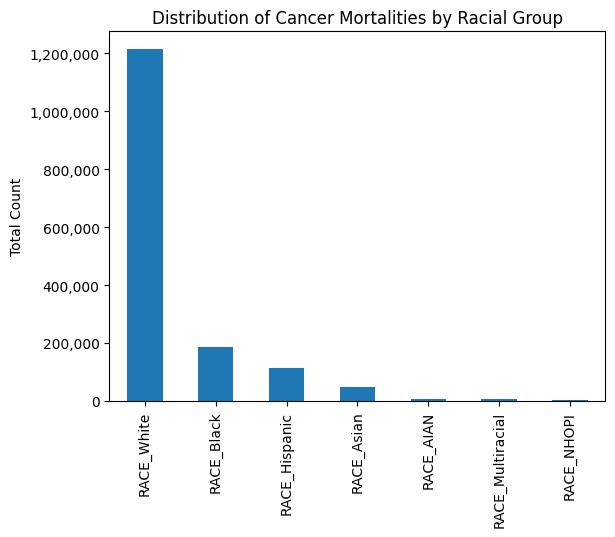

In [30]:
race_counts = cancer_deaths[racial_groups].sum().sort_values(ascending=False)
ax = race_counts.plot(kind='bar')
ax.set_title("Distribution of Cancer Mortalities by Racial Group")
ax.set_ylabel('Total Count')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
print(race_counts)

In [55]:
cols_to_drop = ethnic_groups + racial_groups

X = cancer_deaths.drop(columns=cols_to_drop)

y_white = cancer_deaths['RACE_White']
y_AIAN = cancer_deaths['RACE_AIAN']
y_asian = cancer_deaths['RACE_Asian']
y_black = cancer_deaths['RACE_Black']
y_hispanic = cancer_deaths['RACE_Hispanic']
y_multiracial = cancer_deaths['RACE_Multiracial']
y_NHOPI = cancer_deaths['RACE_NHOPI']

In [17]:
# White
race = 'WHITE'
X_train, X_test, y_train, y_test = train_test_split(X, y_white, test_size=0.2, random_state=random_state)

# Baseline model
dtc_white = DecisionTreeClassifier()
dtc_white.fit(X_train, y_train)
y_pred_white = dtc_white.predict(X_test)

print(f'===== BASELINE MODEL (RACE = {race}) =====')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_white))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_white))

baseline_feature_importance = pd.DataFrame(dtc_white.feature_importances_, index=X.columns, columns=['Importance'])
print('\nFeature Importance (Top 20):')
print(baseline_feature_importance.sort_values(by='Importance', ascending=False).head(20))


===== BASELINE MODEL (RACE = WHITE) =====

Confusion Matrix:
[[ 25111  47721]
 [ 56397 186469]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.31      0.34      0.33     72832
         1.0       0.80      0.77      0.78    242866

    accuracy                           0.67    315698
   macro avg       0.55      0.56      0.55    315698
weighted avg       0.68      0.67      0.68    315698


Feature Importance (Top 20):
                                                    Importance
AGE                                                   0.217304
MONTH_OF_DEATH                                        0.198333
WEEKDAY_OF_DEATH                                      0.154162
DATA_YEAR                                             0.085056
EDUCATION_CODED                                       0.067575
CAUSE_RECODE_113                                      0.025854
PLACE_OF_DEATH_CODED                                  0.020652
MARITAL_STATUS_Neve

#### Baseline Decision Tree Classifier for White cancer mortalities

Key insights:
  - The baseline model performs strongly in precision ($TP / (TP + FP)$) with 80% for classifying White cancer mortalities. However, it struggles significantly to predict non-white cancer mortalities based on precision (31%).
  - There is a strong recall ($TP / (TP + FN)$) for white cancer mortalities at 77%, a slight decrease compared to its precision score. However, there was a slight increase in recall for non-white cancer mortalities (34%) compared to its precision score (31%).
  - In terms of the model's F1 scores ($2 * TP / (2 * TP + FP + FN)$), there was a strong score for white cancer mortalities (78%). In comparison, for non-white cancer mortalities the F1 score was quite low (31%).
  - The model's overal weighted averages for precision (68%), recall (67%), and F1 score (68%) are somewhat strong but this model can definitely be improved upon by hypertuning and using cross validation. It's overall accuracy is 67%.

In [56]:
# ==========================================================================
# =========================== HYPERTUNED VERSION ===========================
# ==========================================================================

race = 'WHITE'
X_train, X_test, y_train, y_test = train_test_split(X, y_white, test_size=0.2, random_state=random_state)

# getting a smaller sample size to run hypertuning with same distributions based on the original y_train, then final model will run on full train/test split
X_train_tune, _, y_train_tune, _ = train_test_split(X_train, y_train, train_size=0.1, stratify=y_train, random_state=random_state)

param_grid = {
    'class_weight': ['balanced', None],
    'max_depth': [2, 4, 6, 8],
    'min_samples_split': [2, 4, 10],
    'min_samples_leaf': [2, 4, 10],
    'criterion': ['gini', 'entropy']
}

# Hypertuned model
grid_search_white = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=random_state),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=2,
    verbose=1
)

grid_search_white.fit(X_train_tune, y_train_tune)

print('Best Parameters:')
print(grid_search_white.best_params_)

best_dtc_white = grid_search_white.best_estimator_
best_dtc_white.fit(X_train, y_train)

y_pred_tuned_white = best_dtc_white.predict(X_test)

print(f'===== BASELINE MODEL (RACE = {race}) =====')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_tuned_white))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned_white))

baseline_feature_importance_tuned = pd.DataFrame(best_dtc_white.feature_importances_, index=X.columns, columns=['Importance'])
print('\nFeature Importance (Top 20):')
print(baseline_feature_importance_tuned.sort_values(by='Importance', ascending=False).head(20))

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best Parameters:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2}
===== BASELINE MODEL (RACE = WHITE) =====

Confusion Matrix:
[[ 10479  62353]
 [  7162 235704]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.59      0.14      0.23     72832
         1.0       0.79      0.97      0.87    242866

    accuracy                           0.78    315698
   macro avg       0.69      0.56      0.55    315698
weighted avg       0.75      0.78      0.72    315698


Feature Importance (Top 20):
                                                    Importance
EDUCATION_CODED                                       0.315417
MARITAL_STATUS_Never Married                          0.196912
AGE                                                   0.139985
PLACE_OF_DEATH_CODED                                  0.080728
CAUSE_OF_DEATH_Mal

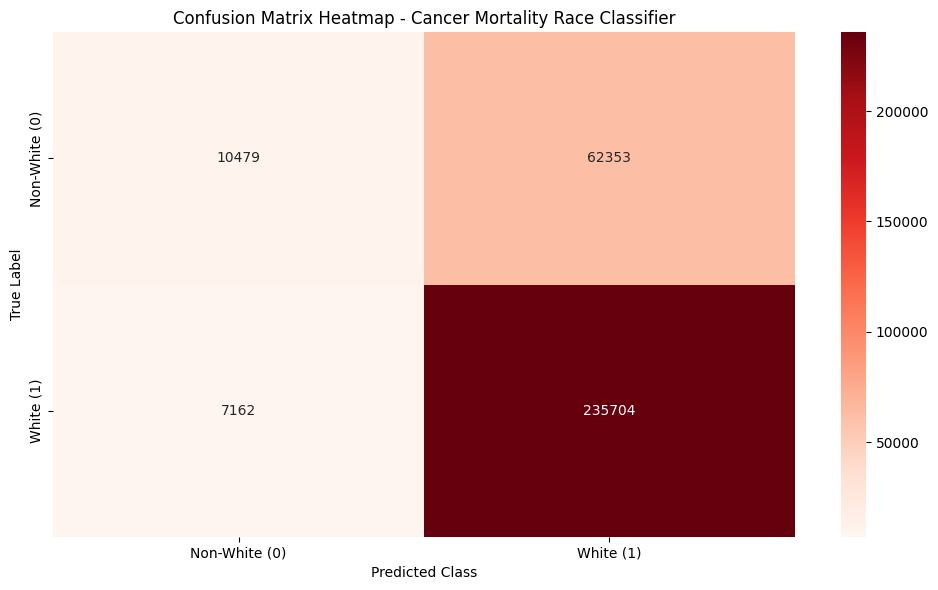

In [58]:
cm = confusion_matrix(y_test, y_pred_tuned_white)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Reds',cbar=True,
            xticklabels=['Non-White (0)', 'White (1)'],
            yticklabels=['Non-White (0)', 'White (1)'])

plt.title(f'Confusion Matrix Heatmap - Cancer Mortality Race Classifier')
plt.xlabel('Predicted Class')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

#### Model comparisons (Baseline vs. Hypertuned)

Confusion Matrix differences:
  - TN: 25,111  vs. 10,479  | Reduction of 14,632 (WORSE)
  - FN: 56,397  vs. 7,162   | Reduction of 49,235 (BETTER)
  - FP: 47,721  vs. 62,353  | Increase of 14,632  (WORSE)
  - TP: 186,469 vs. 235,704 | Increase of 49,235  (BETTER)

In terms of the confusion matrices, the hypertuned model performed better with reducing its false negatives and increasing its true positives. This means that it reduced the baseline model's inaccurate classifications (non-white sample when in reality it's a white sample) and increased its accuracy of true positive classifications (white sample when the sample is white).

Classification report differences:
  - Precision:
    - 0: 31% vs. 59%
    - 1: 80% vs. 79%
  - Recall:
    - 0: 34% vs. 14%
    - 1: 77% vs. 97%
  - F1-score:
    - 0: 33% vs. 23%
    - 1: 78% vs. 87%
  - Accuracy:
    - 67% vs. 78%
  - weighted avg:
    - precision: 68% vs. 75%
    - recall:    67% vs. 78%
    - f1-score:  68% vs. 72%

We can see there are benefits and drawbacks to each model when it comes to the classification report. For example, For precision, there was a slight decrease in White classifications (79% when the baseline was 80%) but a massive jump in non-white precision (59% compared to the baselin of 31%). For recall, the baseline was a better model at capturing non-white samples (34% vs. 14%) but the hypertuned model was better for white samples (97% compared to the baseline recall of 77%). The same pattern continues with the F1 score as the hypertuned model's F1 decreased from 33% to 23% for non-white samples but increased from 78% to 87% for white samples. The accuracy of the hypertuned model was better (78% vs. baseline of 67%). Ultimately, the hypertuned model is better with classification compared to the baseline model but there are still some drawbacks to consider since there are still a massive amount of false positives.

In [20]:
# AIAN

race = 'AIAN'
X_train, X_test, y_train, y_test = train_test_split(X, y_AIAN, test_size=0.2, random_state=random_state)

# Baseline model
dtc_AIAN = DecisionTreeClassifier()
dtc_AIAN.fit(X_train, y_train)
y_pred_AIAN = dtc_AIAN.predict(X_test)

print(f'===== BASELINE MODEL (RACE = {race}) =====')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_AIAN))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_AIAN))

baseline_feature_importance_AIAN = pd.DataFrame(dtc_AIAN.feature_importances_, index=X.columns, columns=['Importance'])
print('\nFeature Importance (Top 20):')
print(baseline_feature_importance_AIAN.sort_values(by='Importance', ascending=False).head(20))

===== BASELINE MODEL (RACE = AIAN) =====

Confusion Matrix:
[[311775   2401]
 [  1503     19]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    314176
         1.0       0.01      0.01      0.01      1522

    accuracy                           0.99    315698
   macro avg       0.50      0.50      0.50    315698
weighted avg       0.99      0.99      0.99    315698


Feature Importance (Top 20):
                                                    Importance
AGE                                                   0.205099
MONTH_OF_DEATH                                        0.189023
WEEKDAY_OF_DEATH                                      0.155960
DATA_YEAR                                             0.099289
EDUCATION_CODED                                       0.042969
PLACE_OF_DEATH_CODED                                  0.025896
SEX_Male                                              0.019545
SEX_Female          

#### Baseline Decision Tree Classifier for AIAN cancer mortalities

Key insights:
  - The baseline model performs very poorly in precision with 1% for classifying AIAN cancer mortalities. However, the precision for non-AIAN was 100% (1.00). This is due to the significant imbalance in AIAN versus non-AIAN samples (1,522 vs. 314,176).
  - There is a very weak recall ($TP / (TP + FN)$) for AIAN cancer mortalities at 1%. However, there was no change in recall for non-AIAN cancer mortalities (99%) compared to its precision score (99%).
  - In terms of the model's F1 scores ($2 * TP / (2 * TP + FP + FN)$), there was a very weak score for AIAN cancer mortalities (1%). In comparison, for non-AIAN cancer mortalities the F1 score was very strong (99%).
  - The model's overall weighted averages for precision, recall, and F1 score are all 99%. This model is great at predicting non-AIAN in terms of TN vs FP (311,775 vs. 2,401), but its limitation is with FP vs. TN (1,503 vs. 19). This model needs significant hyperparameter tuning and cross-validation because its overall accuracy of 99% is heavily biased by the majority class (non-AIAN) and fails to capture the minority class (AIAN).

In [21]:
# Asian

race = 'Asian'
X_train, X_test, y_train, y_test = train_test_split(X, y_asian, test_size=0.2, random_state=random_state)

# Baseline model
dtc_asian = DecisionTreeClassifier()
dtc_asian.fit(X_train, y_train)
y_pred_asian = dtc_asian.predict(X_test)

print(f'===== BASELINE MODEL (RACE = {race}) =====')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_asian))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_asian))

baseline_feature_importance_asian = pd.DataFrame(dtc_asian.feature_importances_, index=X.columns, columns=['Importance'])
print('\nFeature Importance (Top 20):')
print(baseline_feature_importance_asian.sort_values(by='Importance', ascending=False).head(20))

===== BASELINE MODEL (RACE = Asian) =====

Confusion Matrix:
[[294840  11439]
 [  8751    668]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97    306279
         1.0       0.06      0.07      0.06      9419

    accuracy                           0.94    315698
   macro avg       0.51      0.52      0.51    315698
weighted avg       0.94      0.94      0.94    315698


Feature Importance (Top 20):
                                                    Importance
AGE                                                   0.258552
MONTH_OF_DEATH                                        0.202677
WEEKDAY_OF_DEATH                                      0.166316
DATA_YEAR                                             0.098616
EDUCATION_CODED                                       0.034577
CAUSE_RECODE_113                                      0.027183
PLACE_OF_DEATH_CODED                                  0.014973
SEX_Male           

Again, very poor performance with actually predicting Asian but it can predict non-Asian very well.

In [22]:
# Black

race = 'Black'
X_train, X_test, y_train, y_test = train_test_split(X, y_black, test_size=0.2, random_state=random_state)

# Baseline model
dtc_black = DecisionTreeClassifier()
dtc_black.fit(X_train, y_train)
y_pred_black = dtc_black.predict(X_test)

print(f'===== BASELINE MODEL (RACE = {race}) =====')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_black))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_black))

baseline_feature_importance_black = pd.DataFrame(dtc_black.feature_importances_, index=X.columns, columns=['Importance'])
print('\nFeature Importance (Top 20):')
print(baseline_feature_importance_black.sort_values(by='Importance', ascending=False).head(20))

===== BASELINE MODEL (RACE = Black) =====

Confusion Matrix:
[[243597  34546]
 [ 30015   7540]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.88      0.88    278143
         1.0       0.18      0.20      0.19     37555

    accuracy                           0.80    315698
   macro avg       0.53      0.54      0.54    315698
weighted avg       0.81      0.80      0.80    315698


Feature Importance (Top 20):
                                                    Importance
AGE                                                   0.227943
MONTH_OF_DEATH                                        0.200149
WEEKDAY_OF_DEATH                                      0.158262
DATA_YEAR                                             0.091053
EDUCATION_CODED                                       0.045429
CAUSE_RECODE_113                                      0.029958
MARITAL_STATUS_Never Married                          0.023829
PLACE_OF_DEATH_CODE

Somewhat of a better model compared to other minority groups but the accuracy is heavily biased by the imbalance in non-Black vs. Black samples.

In [23]:
# Hispanic

race = 'Hispanic'
X_train, X_test, y_train, y_test = train_test_split(X, y_hispanic, test_size=0.2, random_state=random_state)

# Baseline model
dtc_hispanic = DecisionTreeClassifier()
dtc_hispanic.fit(X_train, y_train)
y_pred_hispanic = dtc_hispanic.predict(X_test)

print(f'===== BASELINE MODEL (RACE = {race}) =====')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_hispanic))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_hispanic))

baseline_feature_importance_hispanic = pd.DataFrame(dtc_hispanic.feature_importances_, index=X.columns, columns=['Importance'])
print('\nFeature Importance (Top 20):')
print(baseline_feature_importance_hispanic.sort_values(by='Importance', ascending=False).head(20))

===== BASELINE MODEL (RACE = Hispanic) =====

Confusion Matrix:
[[270973  22100]
 [ 18204   4421]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93    293073
         1.0       0.17      0.20      0.18     22625

    accuracy                           0.87    315698
   macro avg       0.55      0.56      0.56    315698
weighted avg       0.88      0.87      0.88    315698


Feature Importance (Top 20):
                                                    Importance
AGE                                                   0.205751
MONTH_OF_DEATH                                        0.186557
WEEKDAY_OF_DEATH                                      0.145977
DATA_YEAR                                             0.086230
EDUCATION_CODED                                       0.082631
CAUSE_RECODE_113                                      0.031674
MARITAL_STATUS_Married                                0.019502
PLACE_OF_DEATH_C

Similar in predictive power to the Black classification decision tree model where the accuracy is heavily biased by the imbalance in samples from Hispanic vs. non-Hispanic

In [24]:
# Multiracial

race = 'Multiracial'
X_train, X_test, y_train, y_test = train_test_split(X, y_multiracial, test_size=0.2, random_state=random_state)

# Baseline model
dtc_multi = DecisionTreeClassifier()
dtc_multi.fit(X_train, y_train)
y_pred_multi = dtc_multi.predict(X_test)

print(f'===== BASELINE MODEL (RACE = {race}) =====')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_multi))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_multi))

baseline_feature_importance_multi = pd.DataFrame(dtc_multi.feature_importances_, index=X.columns, columns=['Importance'])
print('\nFeature Importance (Top 20):')
print(baseline_feature_importance_multi.sort_values(by='Importance', ascending=False).head(20))

===== BASELINE MODEL (RACE = Multiracial) =====

Confusion Matrix:
[[312454   1914]
 [  1321      9]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    314368
         1.0       0.00      0.01      0.01      1330

    accuracy                           0.99    315698
   macro avg       0.50      0.50      0.50    315698
weighted avg       0.99      0.99      0.99    315698


Feature Importance (Top 20):
                                                    Importance
AGE                                                   0.188425
MONTH_OF_DEATH                                        0.183369
WEEKDAY_OF_DEATH                                      0.149517
DATA_YEAR                                             0.095583
EDUCATION_CODED                                       0.040643
PLACE_OF_DEATH_CODED                                  0.025066
MARITAL_STATUS_Married                                0.023938
CAUSE_RECODE_

Like the AIAN model, essentially the whole model's accuracy is from classifying non-Multiracial and is essentially completely inaccurate (1% across precision, recall, and f1 score).

In [25]:
# NHOPI

race = 'NHOPI'
X_train, X_test, y_train, y_test = train_test_split(X, y_NHOPI, test_size=0.2, random_state=random_state)

# Baseline model
dtc_NHOPI = DecisionTreeClassifier()
dtc_NHOPI.fit(X_train, y_train)
y_pred_NHOPI = dtc_NHOPI.predict(X_test)

print(f'===== BASELINE MODEL (RACE = {race}) =====')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_NHOPI))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_NHOPI))

baseline_feature_importance_NHOPI = pd.DataFrame(dtc_NHOPI.feature_importances_, index=X.columns, columns=['Importance'])
print('\nFeature Importance (Top 20):')
print(baseline_feature_importance_NHOPI.sort_values(by='Importance', ascending=False).head(20))

===== BASELINE MODEL (RACE = NHOPI) =====

Confusion Matrix:
[[314627    690]
 [   380      1]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    315317
         1.0       0.00      0.00      0.00       381

    accuracy                           1.00    315698
   macro avg       0.50      0.50      0.50    315698
weighted avg       1.00      1.00      1.00    315698


Feature Importance (Top 20):
                                                    Importance
AGE                                                   0.194953
MONTH_OF_DEATH                                        0.174318
WEEKDAY_OF_DEATH                                      0.168052
DATA_YEAR                                             0.106958
EDUCATION_CODED                                       0.041602
MARITAL_STATUS_Married                                0.025627
PLACE_OF_DEATH_Home                                   0.021723
SEX_CODED_F        

This is the worst model since it is heavily biased due to the major imbalance in NHOPI vs. non-NHOPI samples in the dataset. The precision, recall, and f1 scores for NHOPI are less than 1%.

## Random Forest Regression

In [35]:
X = cancer_deaths.drop(columns=['AGE'])
y = cancer_deaths['AGE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [40]:
# Baseline

rf = RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=random_state)
rf.fit(X_train, y_train)

y_pred_age = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_age)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_age))
r2 = r2_score(y_test, y_pred_age)
mape = mean_absolute_percentage_error(y_test, y_pred_age) * 100

print(f'============== BASELINE MODEL ==============')
print(f'Mean Absolute Error:         {mae:.4f} years')
print(f'Root Mean Squared Error:    {rmse:.4f} years')
print(f'R2 Score:                    {r2:.4f}')
print(f'Mean Absolute Percent Error: {mape:.4f}%')

============== BASELINE MODEL ==============
Mean Absolute Error:         8.4105 years
Root Mean Squared Error:    10.7092 years
R2 Score:                    0.3168
Mean Absolute Percent Error: 15.0627%


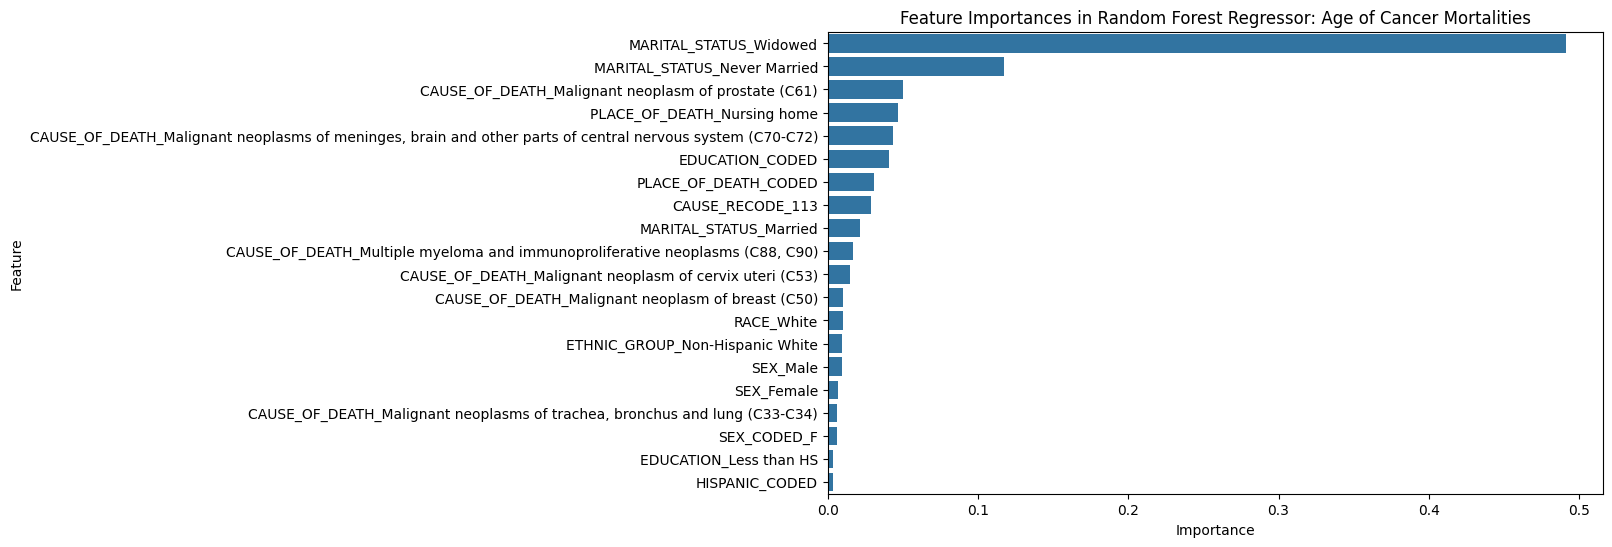

In [43]:
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance.head(20))
plt.title('Feature Importances in Random Forest Regressor: Age of Cancer Mortalities')
plt.show()

#### Findings:

The baseline model does relatively well with a MAE of 8.4 years, RMSE 10.7 years, MAPE of 15%, and an R2 of 31.685%. MAE is highly interpretable for this case because it mans that the cancer mortalities are on average off by 8.4 years. RMSE is more sensitive to the larger errors and increased by 2.3 years compared to MAE. An error within about of decade seems like a decent model but there is definitely room for improvement. The mean absolute percent error is a powerful metric for this capstone because we need to consider proportionality when trying to uncover health disparities. This model is for the full population, but it shows that the error in age predictions is on average off by 15%. This will be an important metric to use if I decide for the final project to create indvidual models for each race, sex, rural/urban, etc categories because it will be able to show proportionately how off the predictions are and wheher we can truly be confident in our predictions based on the quality of data. It is also a very important metric because MAE and RMSE are dominated by the majority elderly ages in the data. This gives us the ability to see how it performs on younger populations as well while the MAE and RMSE wouldn't capture that as well. For a health related project, an R2 score of 31.68% is a strong score because generally an R2 greater than 15% is considered meaningful in clinical research.

#### Feature importance:
The most interesting factors for this random forest model that help predict `AGE` have to do with marital status (widowed or not, married before or not), certain cancers (prostate, meninges, brain, central nervous system), died at a nursing home or not, and level of education. This shows that there may be a social aspect that contributes to the age of death from cancer on whether they have a support network (most commonly their spouse) and the education level (which may be more of an economic influencer as in history the higher level of education leads to higher potential income).

In [48]:
# ==========================================================================
# =========================== HYPERTUNED VERSION ===========================
# ==========================================================================


# getting a smaller sample size to run hypertuning based on the original y_train, then final model will run on full train/test split
X_train_tune, _, y_train_tune, _ = train_test_split(X_train, y_train, train_size=0.1, random_state=random_state)

param_dist = {
    'n_estimators': [100, 200, 500],
    'criterion': ['squared_error'],
    'max_depth': [5, 10, 12, 15],
    'min_samples_split': [2, 4, 10],
    'min_samples_leaf': [2, 5, 10, 25],
    'max_features': [5, 10, 25, 'sqrt']
}

# Hypertuned model
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=random_state),
    param_distributions=param_dist,
    n_iter= 30,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

random_search_rf.fit(X_train_tune, y_train_tune)

print('Best Parameters:')
print(random_search_rf.best_params_)

best_rf = random_search_rf.best_estimator_
best_rf.set_params(n_jobs=-1)

print('Training final model on full training data split')
best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
mape = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

print(f'============== HYPERTUNED MODEL ==============')
print(f'Mean Absolute Error:         {mae:.4f} years')
print(f'Root Mean Squared Error:    {rmse:.4f} years')
print(f'R2 Score:                    {r2:.4f}')
print(f'Mean Absolute Percent Error: {mape:.4f}%')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 25, 'max_depth': 15, 'criterion': 'squared_error'}
Training final model on full training data split
============== HYPERTUNED MODEL ==============
Mean Absolute Error:         8.3083 years
Root Mean Squared Error:    10.5591 years
R2 Score:                    0.3358
Mean Absolute Percent Error: 15.1310%


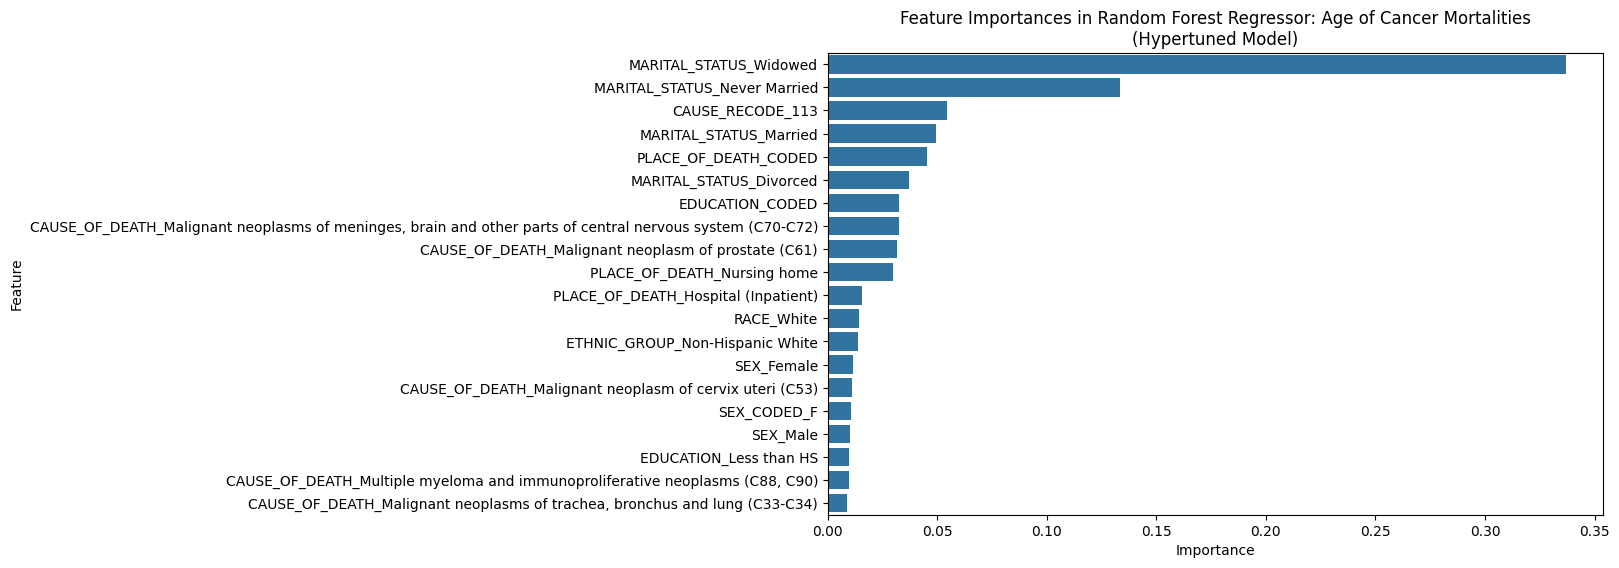

In [51]:
rf_tuned_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_tuned_feature_importance.head(20))
plt.title('Feature Importances in Random Forest Regressor: Age of Cancer Mortalities\n(Hypertuned Model)')
plt.show()

#### Comparison between baseline and hypertuned model:
- Mean Absolute Error:          8.4105 years vs. 8.3083 years
- Root Mean Squared Error:     10.7092 years vs. 10.5591 years
- R2 Score:                           31.68% vs. 33.58%
- Mean Absolute Percent Error:        15.06% vs. 15.13%

Overall, the hypertuned model's performance was slightly better in terms of MAE and RMSE but not significantly enough. The R2 score increased slightly which means the model is able to explain more of the variance of the data. However, the model has a slightly higher MAPE. While objectively the model has fit slightly better across most metrics, it is not significant enough in comparison to the baseline model. I will run another round of RandomizedSearchCV.

In [49]:
# ==========================================================================
# ========================= HYPERTUNED VERSION V2 ==========================
# ==========================================================================

# increasing the ranges of parameters for round 2 of random search
param_dist_v2 = {
    'n_estimators': [200, 500, 700],
    'criterion': ['squared_error'],
    'max_depth': [12, 15, 20, 22],
    'min_samples_split': [4, 10, 12],
    'min_samples_leaf': [5, 10, 25, 30],
    'max_features': [10, 25, 40, 'sqrt']
}

# Hypertuned model
random_search_rf_v2 = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=random_state),
    param_distributions=param_dist_v2,
    n_iter= 30,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

random_search_rf_v2.fit(X_train_tune, y_train_tune)

print('Best Parameters:')
print(random_search_rf_v2.best_params_)

best_rf_v2 = random_search_rf_v2.best_estimator_
best_rf_v2.set_params(n_jobs=-1)

print('Training final model on full training data split')
best_rf_v2.fit(X_train, y_train)

y_pred_rf_v2 = best_rf_v2.predict(X_test)

mae_v2 = mean_absolute_error(y_test, y_pred_rf_v2)
rmse_V2 = np.sqrt(mean_squared_error(y_test, y_pred_rf_v2))
r2_v2 = r2_score(y_test, y_pred_rf_v2)
mape_v2 = mean_absolute_percentage_error(y_test, y_pred_rf_v2) * 100

print(f'============== HYPERTUNED MODEL ==============')
print(f'Mean Absolute Error:         {mae_v2:.4f} years')
print(f'Root Mean Squared Error:    {rmse_V2:.4f} years')
print(f'R2 Score:                    {r2_v2:.4f}')
print(f'Mean Absolute Percent Error: {mape_v2:.4f}%')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 40, 'max_depth': 12, 'criterion': 'squared_error'}
Training final model on full training data split
============== HYPERTUNED MODEL ==============
Mean Absolute Error:         8.3362 years
Root Mean Squared Error:    10.5969 years
R2 Score:                    0.3311
Mean Absolute Percent Error: 15.0171%


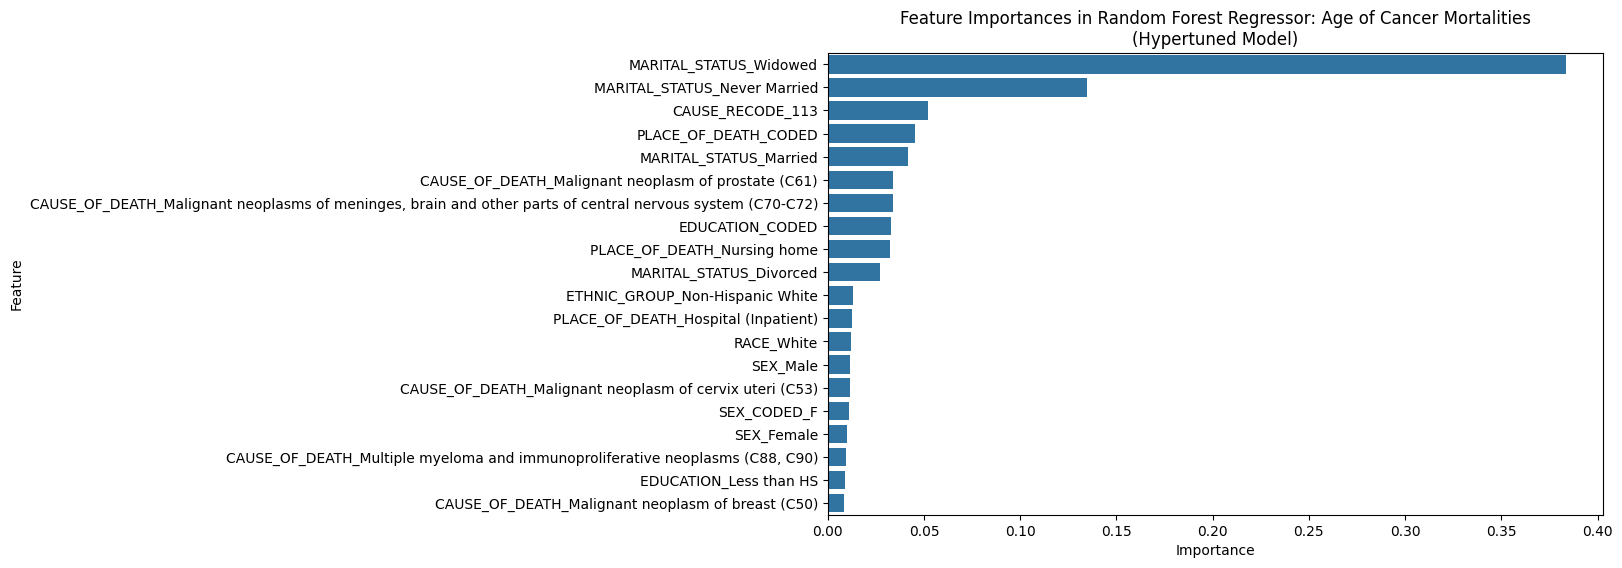

In [52]:
rf_tuned_v2_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_v2.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_tuned_v2_feature_importance.head(20))
plt.title('Feature Importances in Random Forest Regressor: Age of Cancer Mortalities\n(Hypertuned Model)')
plt.show()

#### Comparison between original hypertuned model and round 2 hypertuned model:
- Mean Absolute Error:          8.3083 years vs. 8.3362
- Root Mean Squared Error:     10.5591 years vs. 10.5969
- R2 Score:                           33.58% vs. 33.11%
- Mean Absolute Percent Error:        15.13% vs. 15.017%

Overall, the second round hypertuned random forest model performed slightly worse than the original hypertuned model. This is because there was a very small increase in MAE (0.0279 years) and RMSE (0.0378 years) while a decrease in R2 (0.0047). While the MAPE slightly decreased, all other metrics show that the second hypertuned random forest model did not perform as well. While I have used RandomizedSearchCV for the random forest hyprtuning, there could be more to explore but due to the large dataset and computational cost of running random forests it is more difficult to pinpoint the best hyperparameters in a more methodical way such as GridSearchCV.